In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

from glob import glob

import librosa
import librosa.display
import IPython.display as ipd
from itertools import cycle

sns.set_theme(style="white", palette=None)
color_pal = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_cycle = cycle(plt.rcParams["axes.prop_cycle"].by_key()["color"])

In [7]:
# Extract files

file1 = glob('./kvae-audio/input_samples/*.wav')
file2 = glob('./kvae-audio/output_samples/*.wav')

In [12]:
# Play audio

ipd.Audio(file1[0])

In [13]:
y1, sr1 = librosa.load(file1[0])
y2, sr2 = librosa.load(file2[0])
# y: raw data
# sr: sample rate

In [14]:
print(y1, sr1)
print(y2, sr2)
print(y1.shape)
print(y2.shape)

[2.83652888e-08 8.80600570e-09 1.01949216e-09 ... 1.11535415e-01
 1.42241850e-01 9.54224169e-02] 22050
[-0.0003266  -0.00048012 -0.00035563 ... -0.05282094 -0.03643107
  0.        ] 22050
(220500,)
(220489,)


<Axes: >

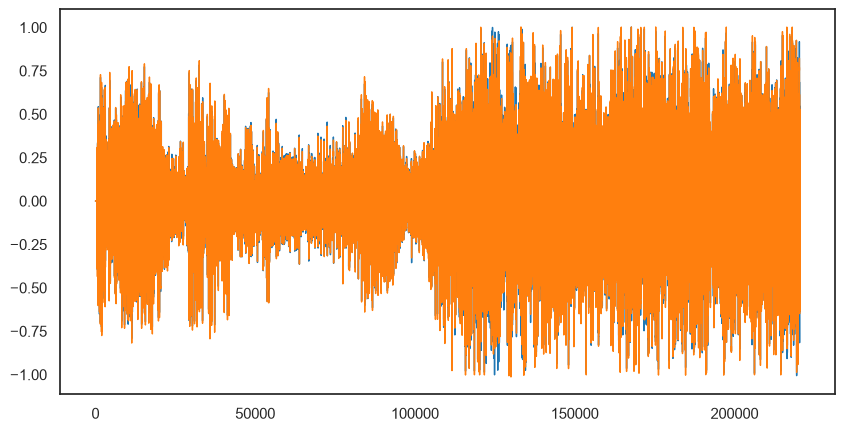

In [15]:
# Plot audio

pd.Series(y1).plot(figsize=(10, 5), lw=1)
pd.Series(y2).plot(figsize=(10, 5), lw=1)

In [9]:
# Get rid of areas with no sound

y_trimmed_1, _ = librosa.effects.trim(y1, top_db = 20) # decibel to trim at
y_trimmed_2, _ = librosa.effects.trim(y2, top_db = 20)

<Axes: >

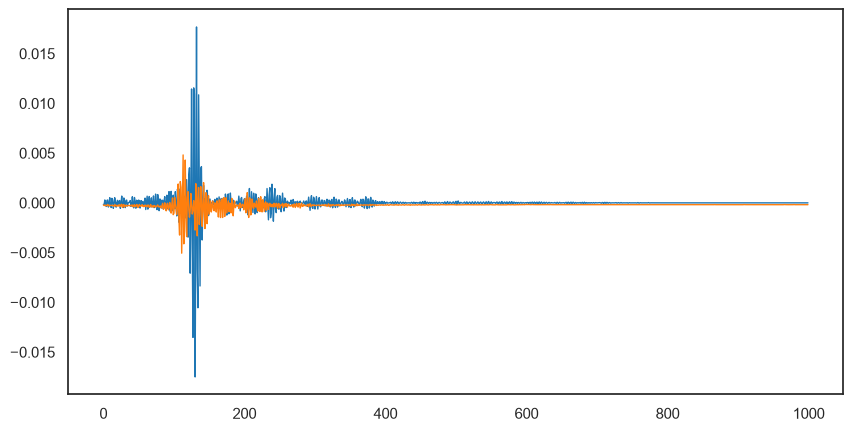

In [6]:
# Zoom:

pd.Series(y1[25000:26000]).plot(figsize=(10, 5), lw=1)
pd.Series(y2[25000:26000]).plot(figsize=(10, 5), lw=1)

In [11]:
D1 = librosa.stft(y1) # Short Time Fourier 
D2 = librosa.stft(y2)
sound_db_1 = librosa.amplitude_to_db(np.abs(D1), ref=np.max)
sound_db_2 = librosa.amplitude_to_db(np.abs(D2), ref = np.max)
sound_db_1.shape
sound_db_2.shape

(1025, 219)

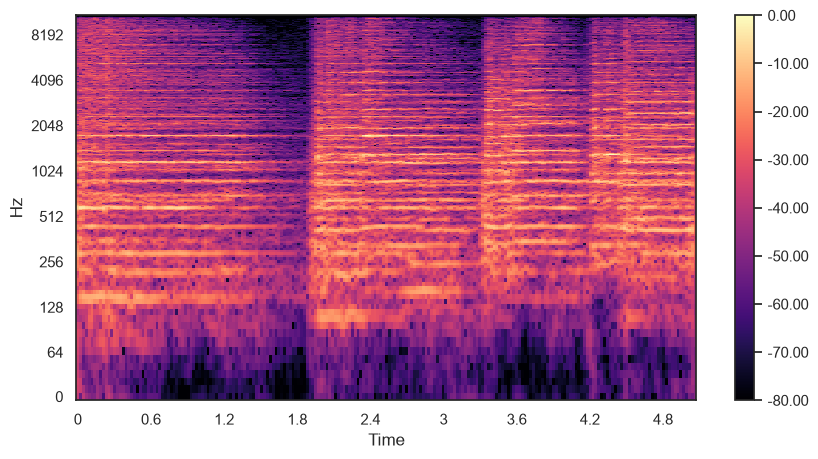

In [12]:
# SPECTOGRAM FOR ORIGINAL AUDIO

fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(sound_db_1, x_axis = 'time', y_axis = 'log', ax = ax)

fig.colorbar(img, ax=ax, format = f'%0.2f')
plt.show()

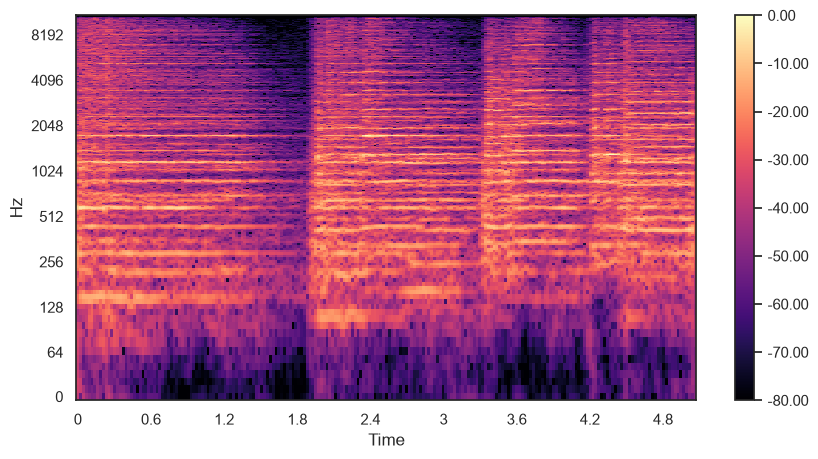

In [13]:
# SPECTOGRAM FOR RECONSTRUCTED AUDIO

fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(sound_db_1, x_axis = 'time', y_axis = 'log', ax = ax)

fig.colorbar(img, ax=ax, format = f'%0.2f')
plt.show()

In [14]:
# MEL SPECTOGRAMS

S1 = librosa.feature.melspectrogram(y=y1, sr=sr1, n_mels = 128,)
S2 = librosa.feature.melspectrogram(y=y2, sr=sr2, n_mels = 128,)

sound_db_mel_1 = librosa.amplitude_to_db(S1, ref=np.max)
sound_db_mel_2 = librosa.amplitude_to_db(S2, ref=np.max)




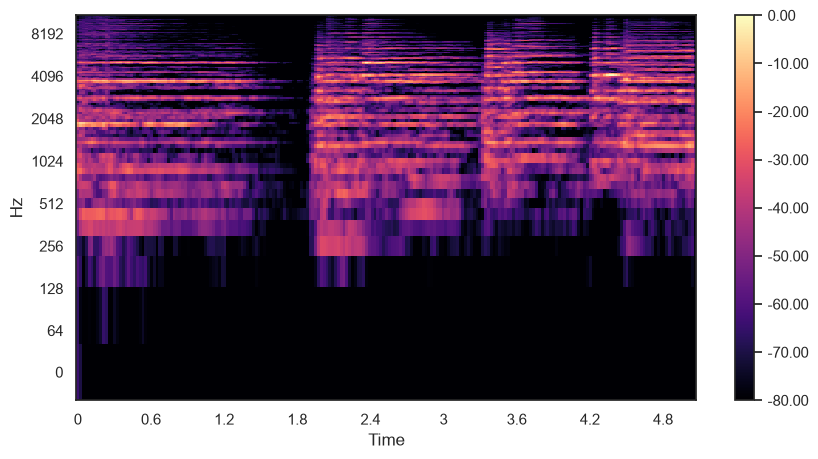

In [ ]:
# MEL ORIGINAL 

fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(sound_db_mel_1, x_axis = 'time', y_axis = 'log', ax = ax)

fig.colorbar(img, ax=ax, format = f'%0.2f')

plt.show()

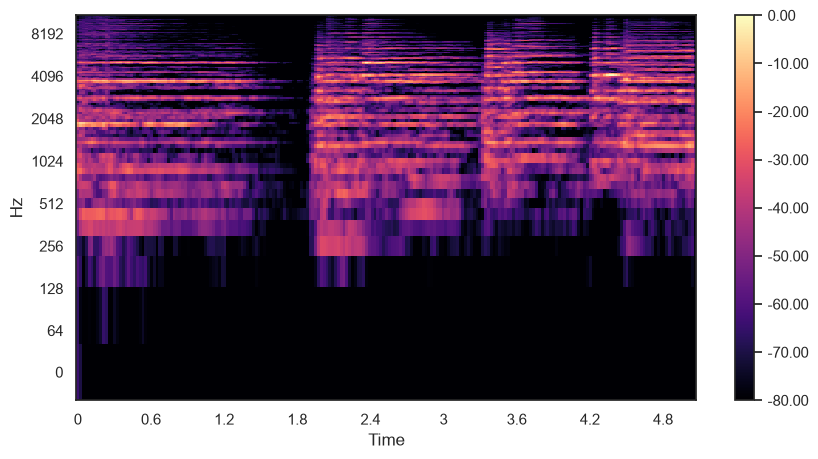

In [16]:
# MEL RECONSTRUCTED
fig, ax = plt.subplots(figsize=(10,5))
img = librosa.display.specshow(sound_db_mel_1, x_axis = 'time', y_axis = 'log', ax = ax)

fig.colorbar(img, ax=ax, format = f'%0.2f')

plt.show()